<a href="https://colab.research.google.com/github/khanrakshinda23-collab/Loan-Approval-/blob/main/Loan_Approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset

In [3]:
df = pd.read_csv("/content/loan_sanction_test.csv", sep = ",", encoding = "latin1", on_bad_lines = "skip", header = 0)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


# Data Exploration

In [4]:
df.shape

(367, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [6]:
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [14]:
categorical_columns = ['Gender','Married','Dependents','Self_Employed']

for i in categorical_columns:
  df[i].fillna(df[i].mode()[0], inplace = True)

/tmp/ipykernel_23295/1235836930.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0], inplace = True)


In [15]:
numerical_cols = ['LoanAmount','Loan_Amount_Term','Credit_History']

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_23295/3405395374.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [16]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Feature Engineering

In [18]:
df['Total_Income'] = (df['ApplicantIncome'] + df['CoapplicantIncome'])

df["Income_Category"] = pd.cut(df["Total_Income"], bins = [0,2500,6000,20000,100000], labels=['Low Income', 'Middle Income','High Income','Very High Income'])

df['LoanAmount_Category'] = pd.cut(df['LoanAmount'], bins=[0,100,200,700], labels=['Small Loan', 'Medium Loan', 'Large Loan'])

df['Applicant_Type'] = np.where(df['Self_Employed'] == 'Yes','Self Employed','Salaried')

df['Credit_Status'] = df['Credit_History'].map({ 1:'Good Credit', 0:'Bad Credit'})

In [19]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income,Income_Category,LoanAmount_Category,Applicant_Type,Credit_Status
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,5720,Middle Income,Medium Loan,Salaried,Good Credit
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,4576,Middle Income,Medium Loan,Salaried,Good Credit
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,6800,High Income,Large Loan,Salaried,Good Credit
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban,4886,Middle Income,Small Loan,Salaried,Good Credit
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,3276,Middle Income,Small Loan,Salaried,Good Credit


# Data Vizualization

### Univariate Analysis
* 1. Applicant Income Distribution (Histogram)
* 2. Loan Amount Distribution (Boxplot)
* 3. Property Area Distribution (Bar Chart)
* 4. Education Distribution (Pie Chart)

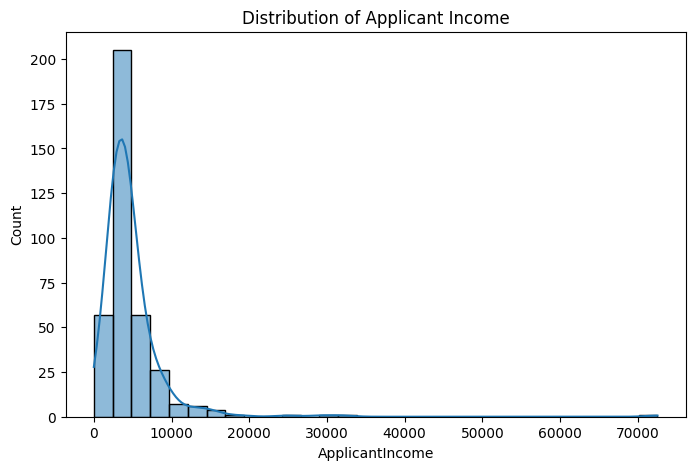

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'],bins=30,kde=True)
plt.title("Distribution of Applicant Income")
plt.show()

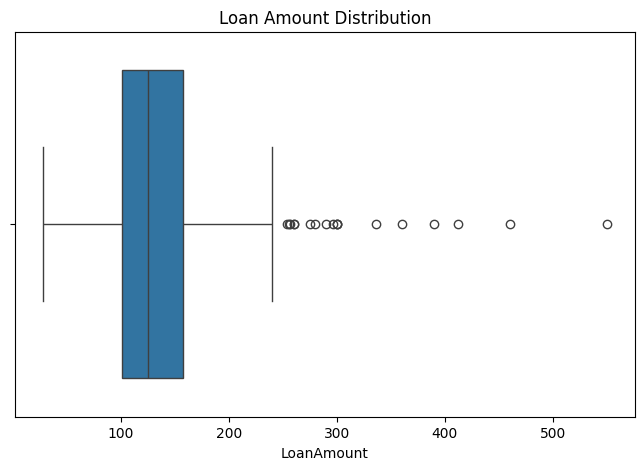

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['LoanAmount'])
plt.title("Loan Amount Distribution")
plt.show()

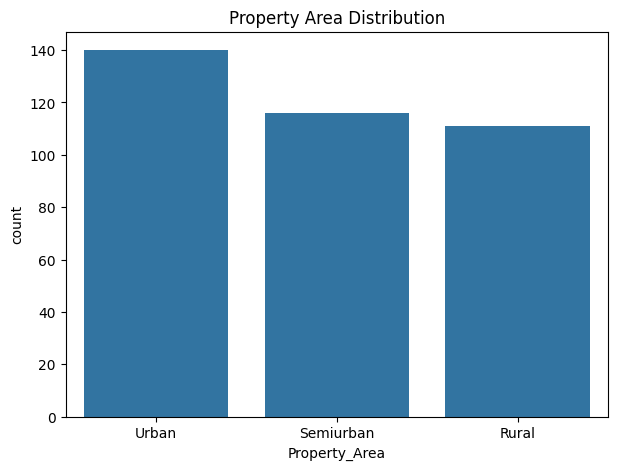

In [26]:
plt.figure(figsize=(7,5))
sns.countplot(x='Property_Area',data=df)
plt.title("Property Area Distribution")
plt.show()

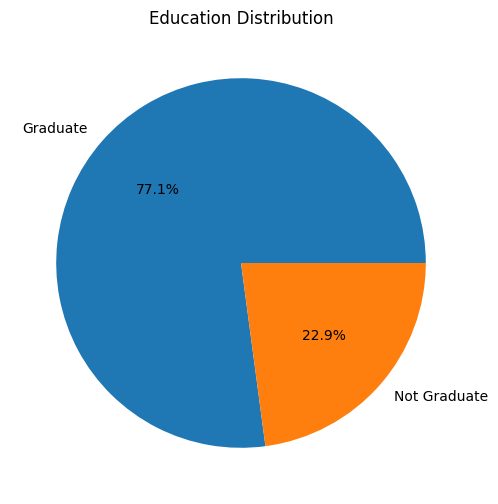

In [40]:
education_counts = df['Education'].value_counts()

plt.figure(figsize=(6,6))

plt.pie( education_counts, labels=education_counts.index, autopct='%1.1f%%')

plt.title("Education Distribution")
plt.show()

### Bivariate Analysis

* 1. Income vs Loan Amount (Scatter Plot)
* 2. Education vs Loan Amount (Boxplot)
* 3. Credit History vs Loan Amount
* 4. Pair Plot

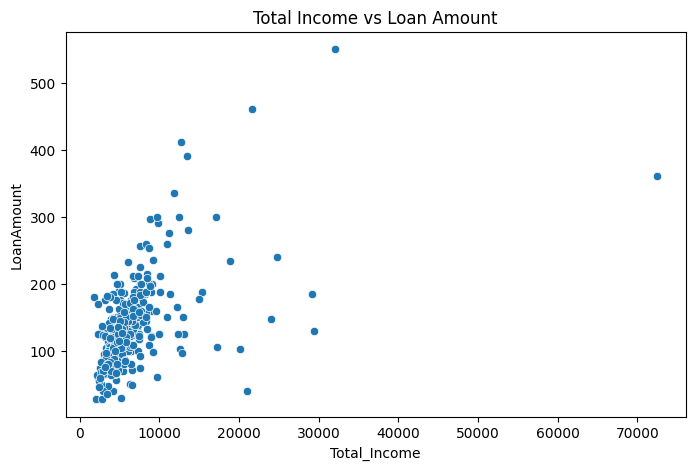

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Total_Income', y='LoanAmount', data=df)
plt.title("Total Income vs Loan Amount")
plt.show()

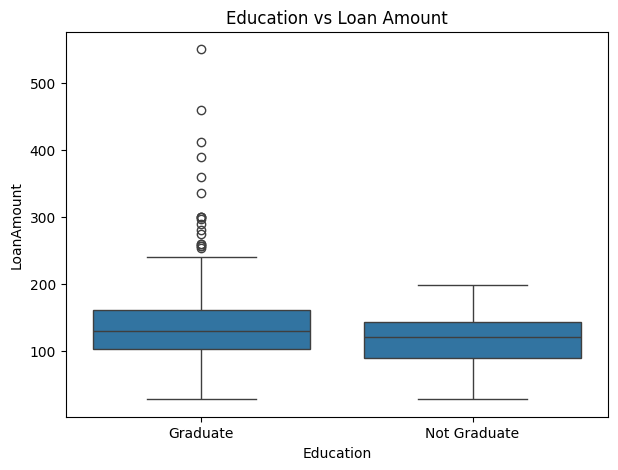

In [29]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Education', y='LoanAmount', data=df)
plt.title("Education vs Loan Amount")
plt.show()

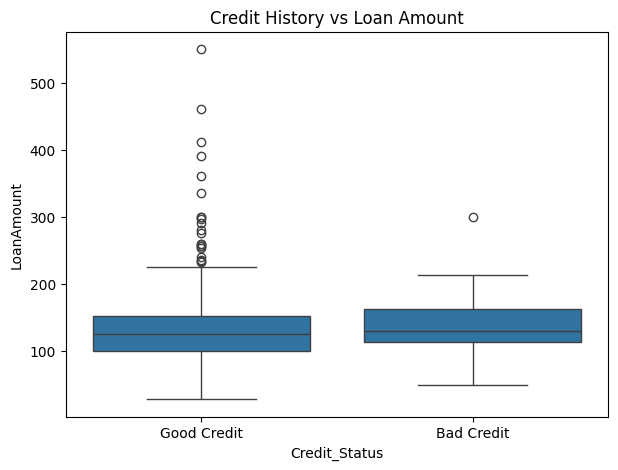

In [30]:
plt.figure(figsize=(7,5))

sns.boxplot(x='Credit_Status', y='LoanAmount', data=df)
plt.title("Credit History vs Loan Amount")
plt.show()

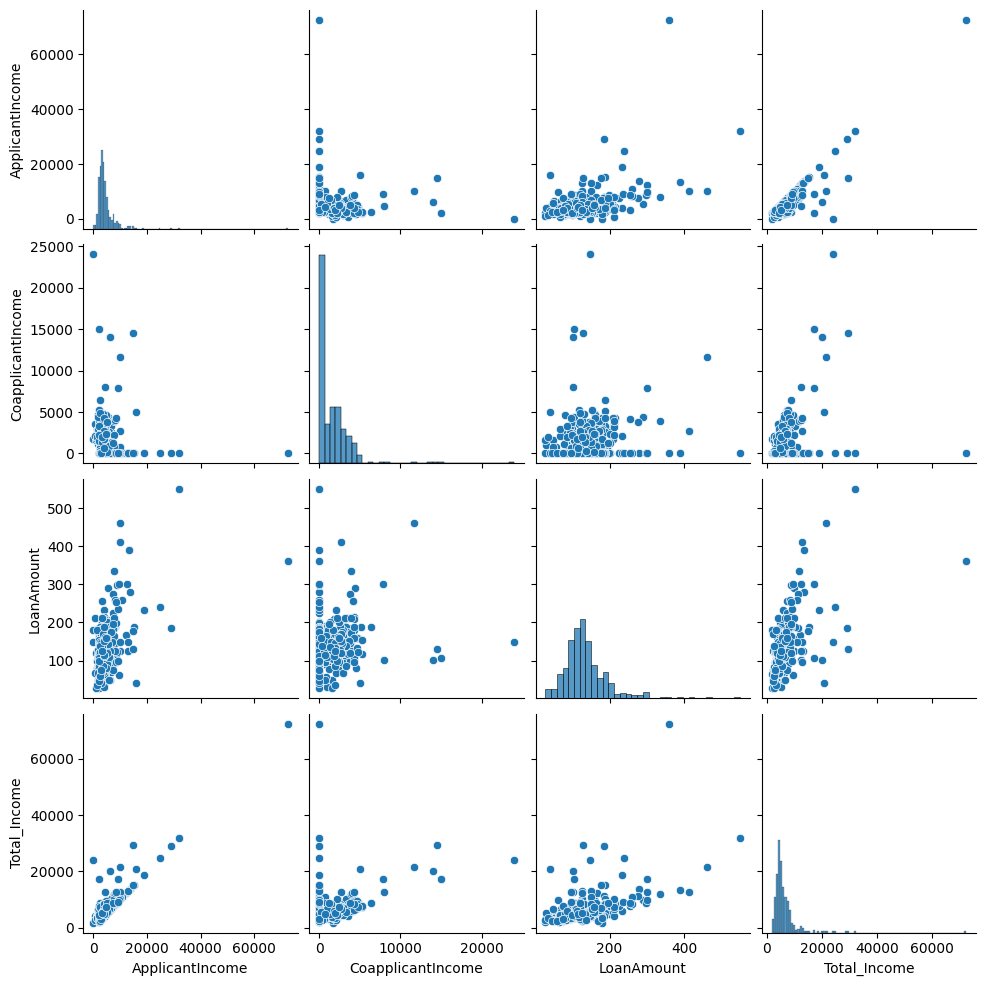

In [47]:
sns.pairplot(df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Total_Income']])
plt.show()

### Multivariate Analysis

* Correlation Heatmap
* 10. Stacked Bar Chart
Property Area vs Education

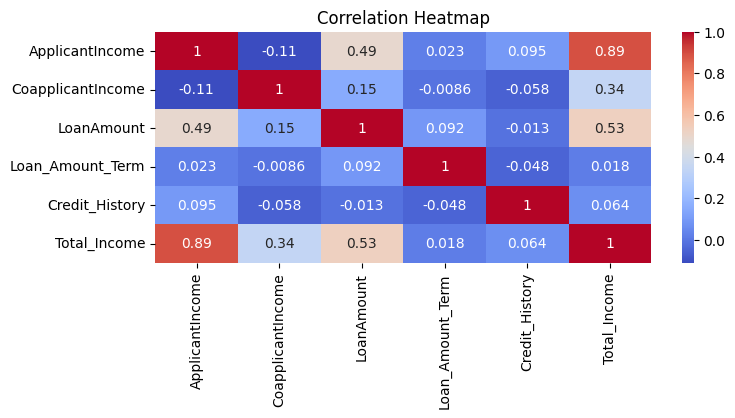

In [43]:
plt.figure(figsize=(8,3))

sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

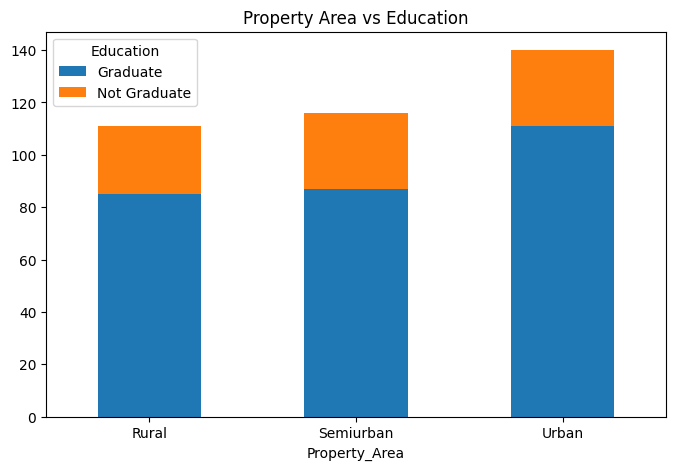

In [34]:
pd.crosstab(df['Property_Area'],df['Education']).plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Property Area vs Education")
plt.xticks(rotation=0)
plt.show()

## 11. Important Business Analysis

* Applicant Type Distribution
* Income Category Distribution
* Top Applicants by Income

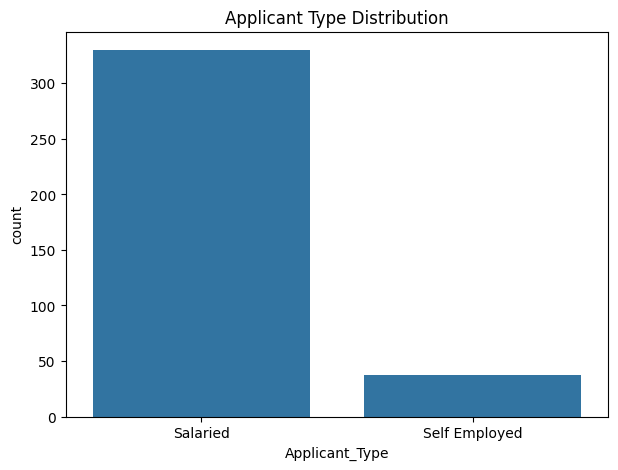

In [35]:
plt.figure(figsize=(7,5))

sns.countplot(x='Applicant_Type', data=df)
plt.title("Applicant Type Distribution")
plt.show()

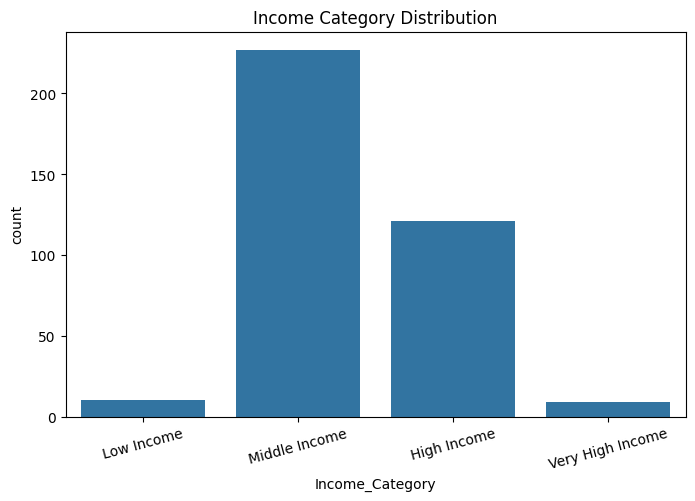

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(x='Income_Category', data=df)
plt.title("Income Category Distribution")
plt.xticks(rotation=15)
plt.show()

In [37]:
df[['Loan_ID','ApplicantIncome']].sort_values(by='ApplicantIncome', ascending=False).head(10)

,Loan_ID,ApplicantIncome
81,LP001428,72529
143,LP001791,32000
279,LP002553,29167
272,LP002485,24797
263,LP002433,18840
323,LP002791,16000
179,LP002017,15312
302,LP002654,14987
230,LP002294,14911
8,LP001059,13633
